- 1

In [38]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [39]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "Mall_Customers.csv"

In [40]:
df = pd.read_csv(CSV_PATH)

In [41]:
print("Shape:", df.shape)

Shape: (200, 5)


In [42]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [43]:
# save CustomerID to a list for later use
customer_id = df["CustomerID"]

In [44]:
# drop CustomerID column as it is not useful for modelling
df = df.drop(columns=["CustomerID"])

In [45]:
# basic dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [46]:
# missing values
df.isnull().sum()

,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [47]:
# check for encoded missing values
for col in df.columns:
  print(df[col].value_counts().head(10))

Gender
Female    112
Male       88
Name: count, dtype: int64
Age
32    11
35     9
31     8
19     8
30     7
49     7
23     6
40     6
36     6
27     6
Name: count, dtype: int64
Annual Income (k$)
54    12
78    12
60     6
48     6
63     6
71     6
62     6
87     6
40     4
43     4
Name: count, dtype: int64
Spending Score (1-100)
42    8
55    7
73    6
46    6
48    5
52    5
50    5
59    5
75    5
35    5
Name: count, dtype: int64


In [48]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0


- 2 - Data Visualization

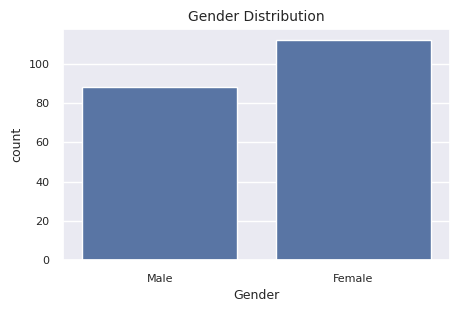

In [49]:
# Gender distribution
plt.figure(figsize=(5, 3))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

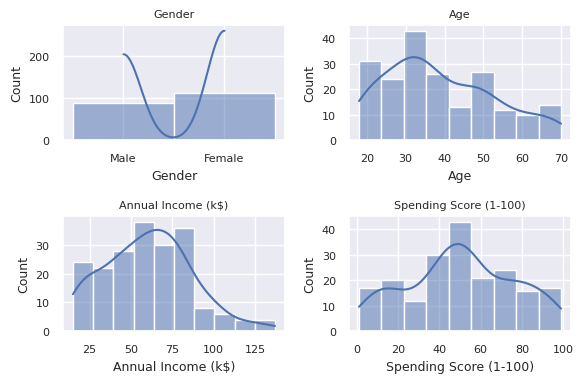

In [50]:
# histogram plot - distribution
fig, axes = plt.subplots(2, 2, figsize=(6, 4))
axes = axes.flatten()

for i, col in enumerate(df.columns):
  sns.histplot(df[col], kde=True, ax=axes[i])
  axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

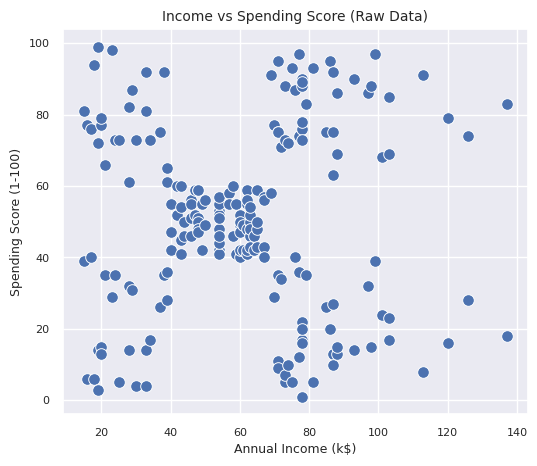

In [51]:
# scatter plot: Income vs Spending
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df,
    s=70
)
plt.title("Income vs Spending Score (Raw Data)")
plt.show()

In [52]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [53]:
# feature selection
columns_to_select = ["Annual Income (k$)", "Spending Score (1-100)"]

X = df[columns_to_select]

In [54]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [55]:
# scale the features (K-means is distance-based)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [56]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

- 3 - Elbow Method - WCSS

(Find best k value)

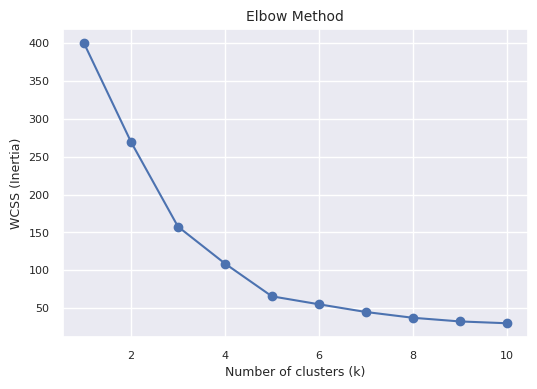

In [57]:
wcss = []
k_range = range(1, 11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.show()

In [58]:
wcss

[399.99999999999994,
 269.69101219276405,
 157.70400815035939,
 108.92131661364358,
 65.56840815571681,
 55.057348270385965,
 44.86475569922555,
 37.22818767758587,
 32.39226763033118,
 29.981897788243703]

- 4 - K-Means Clustering

In [59]:
K_FINAL = 5

In [60]:
kmeans_final = KMeans(
    n_clusters=K_FINAL,
    random_state=RANDOM_STATE,
    n_init=10
)

In [61]:
kmeans_final.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [62]:
clusters = kmeans_final.predict(X_scaled)

In [63]:
clusters

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [64]:
# copy of original df
df_clusters = df.copy(deep=True)

In [65]:
df_clusters

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [66]:
df_clusters["clusters"] = clusters

In [68]:
df_clusters["CustomerID"] = customer_id

In [69]:
df_clusters.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters,CustomerID
0,Male,19,15,39,4,1
1,Male,21,15,81,2,2
2,Female,20,16,6,4,3
3,Female,23,16,77,2,4
4,Female,31,17,40,4,5


- 5 - Evaluation

In [71]:
k_means_score = silhouette_score(X_scaled, df_clusters["clusters"])
print("K-Means Clustering - Silhouette Score:", round(k_means_score, 3))

K-Means Clustering - Silhouette Score: 0.555


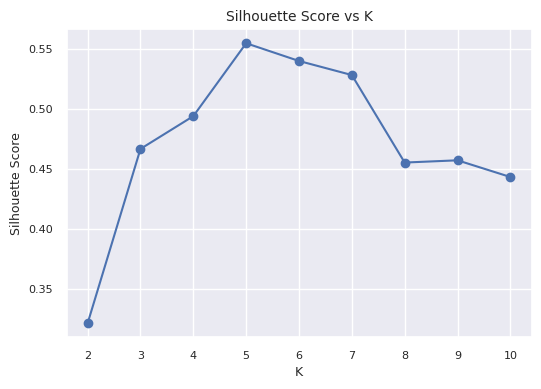

In [73]:
sil_scores = []

for k in range(2, 11):
  model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
  cluster_labels = model.fit_predict(X_scaled)
  sil = silhouette_score(X_scaled, cluster_labels)
  sil_scores.append(sil)

plt.figure(figsize=(6, 4))
plt.plot(range(2, 11), sil_scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

- 6 - Visualize Clusters

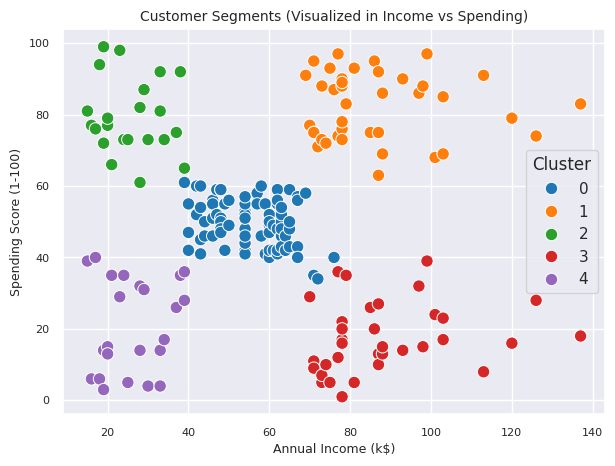

In [75]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=df_clusters["Annual Income (k$)"],
    y=df_clusters["Spending Score (1-100)"],
    hue=df_clusters["clusters"],
    palette="tab10",
    s=80
)

plt.title("Customer Segments (Visualized in Income vs Spending)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()

- 7 - Cluster Interpretation (Business Profiling)

In [76]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [83]:
profile_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

cluster_sizes = df_clusters["clusters"].value_counts().sort_index()
cluster_profile_mean = df_clusters.groupby("clusters")[profile_cols].mean()
cluster_profile_median = df_clusters.groupby("clusters")[profile_cols].median()

print("Cluster Sizes:\n")
print(cluster_sizes)

print("Cluster Profile (Mean):\n")
display(cluster_profile_mean)

print("Cluster Profile (Median):\n")
display(cluster_profile_median)

Cluster Sizes:

clusters
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64
Cluster Profile (Mean):



,Age,Annual Income (k$),Spending Score (1-100)
clusters,,,
0,42.716,55.296,49.519
1,32.692,86.538,82.128
2,25.273,25.727,79.364
3,41.114,88.200,17.114
4,45.217,26.304,20.913


Cluster Profile (Median):



,Age,Annual Income (k$),Spending Score (1-100)
clusters,,,
0,46.000,54.000,50.000
1,32.000,79.000,83.000
2,23.500,24.500,77.000
3,42.000,85.000,16.000
4,46.000,25.000,17.000


In [84]:
df_clusters

,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters,CustomerID
0,Male,19,15,39,4,1
1,Male,21,15,81,2,2
2,Female,20,16,6,4,3
3,Female,23,16,77,2,4
4,Female,31,17,40,4,5
...,...,...,...,...,...,...
195,Female,35,120,79,1,196
196,Female,45,126,28,3,197
197,Male,32,126,74,1,198
198,Male,32,137,18,3,199


- 8 - Segment Assignment Function (for new customers)

In [85]:
def assign_customer_segment(income_k, spending_score, scaler, model):
  new_point = pd.DataFrame(
      [[income_k, spending_score]],
      columns=["Annual Income (k$)", "Spending Score (1-100)"]
  )

  new_point_scaled = scaler.transform(new_point)
  cluster_id = model.predict(new_point_scaled)[0]
  return cluster_id

In [86]:
# Example usage
new_cluster = assign_customer_segment(
    income_k=60,
    spending_score=65,
    scaler=scaler,
    model=kmeans_final
)

print("\n New Customer assigned to cluster:", new_cluster)


 New Customer assigned to cluster: 0
